# Bus route map-matching concept

這個 notebook 用最小資料把概念一層一層疊起來：

1. TDX route shape：公車路線線段。
2. TDX stops：原始站點座標。
3. matched stops：把站點投影到 route shape 上，得到沿線累積里程。
4. bus GPS：把某台公車 GPS 投影到 route shape 上。
5. delay signal：不要直接比較經緯度，改比較同一路線上的 progress。

你可以先改下面的 `ROUTE_NAME`、`DIRECTION`、`SLOT_FILE`、`PLATE_HINT` 來摸資料。

In [1]:
from pathlib import Path
import json
import math
import re

import polars as pl
import matplotlib.pyplot as plt

CWD = Path.cwd()
ROOT = CWD if (CWD / "frontend").exists() else CWD.parent
DATA = ROOT / "frontend" / "public" / "data" / "tdx-bus"

ROUTE_NAME = "205"
DIRECTION = 0
SLOT_FILE = DATA / "archive" / "2026-05-20" / "13-30.json"
ROUTE_CONTEXT_FILE = DATA / "route-context" / f"{ROUTE_NAME}.json"
PLATE_HINT = None  # e.g. "550-U5"; None means choose the first bus on the route.

ROUTE_CONTEXT_FILE, SLOT_FILE

(PosixPath('/Users/unknowntpo/repo/unknowntpo/twfoundry/main/frontend/public/data/tdx-bus/route-context/205.json'),
 PosixPath('/Users/unknowntpo/repo/unknowntpo/twfoundry/main/frontend/public/data/tdx-bus/archive/2026-05-20/13-30.json'))

In [8]:
route_context = json.loads(ROUTE_CONTEXT_FILE.read_text())
snapshot = json.loads(SLOT_FILE.read_text())
print(snapshot.keys())
print(snapshot["schema"])


dict_keys(['schema', 'source', 'captureDate', 'capturedAt', 'slot', 'count', 'routeCount', 'bounds', 'records'])
twfoundry.tdx.citybus.snapshot.v1


## 1. Load and inspect data shape

先用 Polars 看資料長什麼樣。這一步的目的是確認欄位，不急著畫圖。

In [ ]:
route_context = json.loads(ROUTE_CONTEXT_FILE.read_text())
snapshot = json.loads(SLOT_FILE.read_text())
records = snapshot["records"]
vehicle_df = pl.DataFrame(records).with_columns(
    pl.col("BusPosition").struct.field("PositionLon").alias("lon"),
    pl.col("BusPosition").struct.field("PositionLat").alias("lat"),
)

route_vehicle_df = vehicle_df.filter(
    (pl.col("RouteName") == ROUTE_NAME) & (pl.col("Direction") == DIRECTION)
)

print("snapshot records:", vehicle_df.height)
print("route records:", route_vehicle_df.height)
print("route context:", route_context["shapeCount"], "shapes,", route_context["stopOfRouteCount"], "stop-of-route records")
route_vehicle_df.select("PlateNumb", "RouteName", "Direction", "lon", "lat", "Speed", "GPSTime").head(8)

## 2. Pick route shape and stop sequence

TDX 提供兩種不同但相關的資料：

- `Shape`：路線幾何線，像地圖上的黑線。
- `StopOfRoute.Stops`：站點序列，含 `StopSequence` 和站牌座標。

關鍵：站牌座標不一定剛好落在 route shape 上，所以需要投影。

In [6]:
shape = next(s for s in route_context["shapes"] if int(s["Direction"]) == DIRECTION)
stop_of_route = next(s for s in route_context["stopOfRoutes"] if int(s["Direction"]) == DIRECTION)

stops_df = pl.DataFrame([
    {
        "seq": int(stop["StopSequence"]),
        "stop_id": stop["StopID"],
        "name": stop["StopName"].get("Zh_tw") or stop["StopName"].get("En"),
        "lon": float(stop["StopPosition"]["PositionLon"]),
        "lat": float(stop["StopPosition"]["PositionLat"]),
    }
    for stop in stop_of_route["Stops"]
]).sort("seq")

stops_df.head(10)

seq,stop_id,name,lon,lat
i64,str,str,f64,f64
1,"""156480""","""中華科技大學(正門)""",121.609765,25.033828
2,"""34683""","""中華科技大學""",121.611345,25.033428
3,"""156481""","""軍人公墓""",121.612194,25.033295
4,"""34684""","""凌雲站""",121.614489,25.034612
5,"""34685""","""九如里二""",121.61612,25.034863
6,"""34686""","""凌雲五村""",121.616952,25.035872
7,"""34687""","""九如里一""",121.617024,25.037701
8,"""34688""","""胡適公園""",121.617633,25.040597
9,"""34689""","""中研院""",121.616561,25.043422


## 3. Geometry helpers

這裡刻意不用重型 GIS library，先用簡單方法理解：

- 把經緯度轉成局部平面公尺座標。
- 對每個 route segment 做最近點投影。
- 選距離最短的投影點。
- 回傳 `progress_m`：沿 route shape 的累積里程。

In [9]:
EARTH_RADIUS_M = 6_371_008.8

def parse_linestring(wkt: str):
    body = re.search(r"LINESTRING\s*\((.*)\)", wkt, re.I).group(1)
    return [tuple(map(float, part.strip().split())) for part in body.split(",")]

def haversine_m(a, b):
    lon1, lat1 = map(math.radians, a)
    lon2, lat2 = map(math.radians, b)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    x = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_M * math.atan2(math.sqrt(x), math.sqrt(1 - x))

def local_xy(point, origin):
    lon, lat = point
    origin_lon, origin_lat = origin
    lat_scale = math.pi / 180 * EARTH_RADIUS_M
    lon_scale = lat_scale * math.cos(math.radians(origin_lat))
    return ((lon - origin_lon) * lon_scale, (lat - origin_lat) * lat_scale)

def from_local_xy(xy, origin):
    x, y = xy
    origin_lon, origin_lat = origin
    lat_scale = math.pi / 180 * EARTH_RADIUS_M
    lon_scale = lat_scale * math.cos(math.radians(origin_lat))
    return (origin_lon + x / lon_scale, origin_lat + y / lat_scale)

def build_segments(points):
    segments = []
    progress = 0.0
    for a, b in zip(points, points[1:]):
        length = haversine_m(a, b)
        segments.append({"a": a, "b": b, "start_m": progress, "length_m": length})
        progress += length
    return segments, progress

def project_point_to_route(point, segments, route_length_m):
    best = None
    for seg in segments:
        origin = point
        px, py = local_xy(point, origin)
        ax, ay = local_xy(seg["a"], origin)
        bx, by = local_xy(seg["b"], origin)
        dx, dy = bx - ax, by - ay
        denom = dx * dx + dy * dy
        t = 0.0 if denom == 0 else max(0.0, min(1.0, ((px - ax) * dx + (py - ay) * dy) / denom))
        qx, qy = ax + dx * t, ay + dy * t
        dist = math.hypot(px - qx, py - qy)
        progress_m = seg["start_m"] + seg["length_m"] * t
        candidate = {
            "matched_lon": from_local_xy((qx, qy), origin)[0],
            "matched_lat": from_local_xy((qx, qy), origin)[1],
            "distance_to_route_m": dist,
            "progress_m": progress_m,
            "progress_ratio": progress_m / route_length_m if route_length_m else None,
        }
        if best is None or candidate["distance_to_route_m"] < best["distance_to_route_m"]:
            best = candidate
    return best

route_points = parse_linestring(shape["Geometry"])
segments, route_length_m = build_segments(route_points)
route_length_m / 1000

18.574774127630207

## 4. Project stops onto route shape

紅點是 TDX 原始站點，藍點是投影到路線線段後的位置。

如果紅點和藍點距離很大，代表該站點和 route shape 不太一致，後續 delay 判斷要降權。

In [10]:
matched_stops = []
for row in stops_df.iter_rows(named=True):
    projection = project_point_to_route((row["lon"], row["lat"]), segments, route_length_m)
    matched_stops.append({**row, **projection})

matched_stops_df = pl.DataFrame(matched_stops).with_columns(
    (pl.col("progress_m") / 1000).alias("progress_km")
)

matched_stops_df.select(
    "seq", "name", "progress_km", "distance_to_route_m"
).head(12)

seq,name,progress_km,distance_to_route_m
i64,str,f64,f64
1,"""中華科技大學(正門)""",0.000877,5.756744
2,"""中華科技大學""",0.176774,4.187845
3,"""軍人公墓""",0.266538,3.17971
4,"""凌雲站""",0.547489,0.512583
5,"""九如里二""",0.719055,0.392066
…,…,…,…
8,"""胡適公園""",1.404948,3.074213
9,"""中研院""",1.758922,5.144115
10,"""中研新村""",1.96473,2.843188


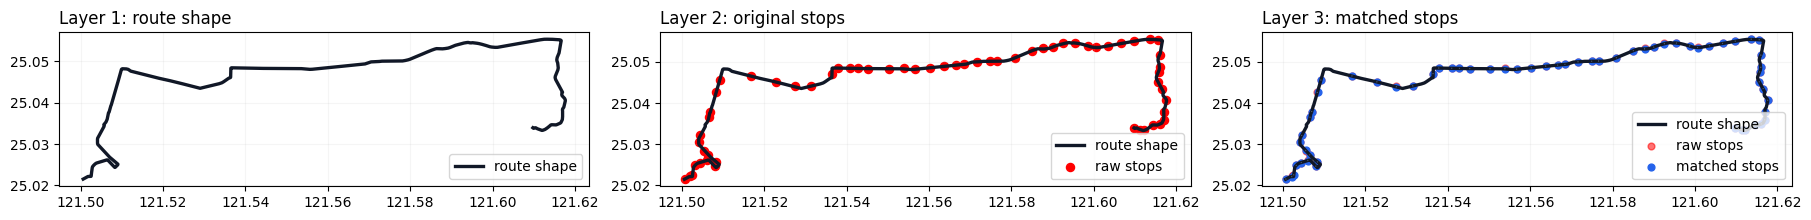

In [12]:
def draw_base(ax, title):
    xs = [p[0] for p in route_points]
    ys = [p[1] for p in route_points]
    ax.plot(xs, ys, color="#111827", linewidth=2.4, label="route shape")
    ax.set_title(title, loc="left")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.12)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

draw_base(axes[0], "Layer 1: route shape")

draw_base(axes[1], "Layer 2: original stops")
axes[1].scatter(stops_df["lon"], stops_df["lat"], s=34, color="red", label="raw stops")

draw_base(axes[2], "Layer 3: matched stops")
axes[2].scatter(stops_df["lon"], stops_df["lat"], s=24, color="red", alpha=0.55, label="raw stops")
axes[2].scatter(matched_stops_df["matched_lon"], matched_stops_df["matched_lat"], s=24, color="#2563eb", label="matched stops")
for row in matched_stops_df.iter_rows(named=True):
    axes[2].plot([row["lon"], row["matched_lon"]], [row["lat"], row["matched_lat"]], color="#94a3b8", alpha=0.45, linewidth=0.8)

for ax in axes:
    ax.legend(loc="lower right")
plt.show()

## 5. Project one bus GPS point

這就是 map matching 的核心：公車 GPS 不一定在路線線上，所以我們找它在 route shape 上最近的位置。

In [13]:
if PLATE_HINT:
    selected_bus = route_vehicle_df.filter(pl.col("PlateNumb") == PLATE_HINT).row(0, named=True)
else:
    selected_bus = route_vehicle_df.row(0, named=True)

bus_point = (float(selected_bus["lon"]), float(selected_bus["lat"]))
bus_projection = project_point_to_route(bus_point, segments, route_length_m)

selected_bus, bus_projection

({'PlateNumb': '550-U5',
  'RouteUID': 'TPE10181',
  'RouteName': '205',
  'Direction': 0,
  'BusPosition': {'PositionLat': 25.022222, 'PositionLon': 121.50258},
  'Speed': 0,
  'Azimuth': 246,
  'GPSTime': '2026-05-20T13:34:41+08:00',
  'UpdateTime': '2026-05-20T13:34:55+08:00',
  'source': 'TDX Historical Bus RealTimeByFrequency City Taipei',
  'freshness': 'fresh',
  'completeness': 1,
  'mode': 'tdx-historical',
  'age': '0s',
  'x': '38.87%',
  'y': '61.62%',
  'lon': 121.50258,
  'lat': 25.022222},
 {'matched_lon': 121.5025671853529,
  'matched_lat': 25.022223126331294,
  'distance_to_route_m': 1.297247520170981,
  'progress_m': 18347.221555116885,
  'progress_ratio': 0.9877493760650992})

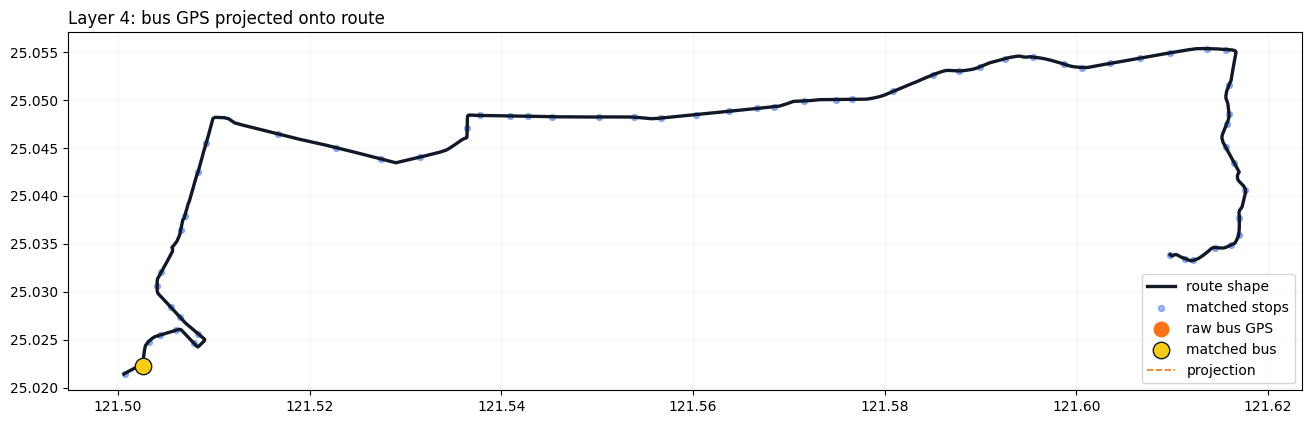

plate,gps_time,speed,route_progress_km,route_progress_pct,distance_to_route_m
str,str,i64,f64,f64,f64
"""550-U5""","""2026-05-20T13:34:41+08:00""",0,18.347222,98.774938,1.297248


In [14]:
fig, ax = plt.subplots(figsize=(13, 7), constrained_layout=True)
draw_base(ax, "Layer 4: bus GPS projected onto route")
ax.scatter(matched_stops_df["matched_lon"], matched_stops_df["matched_lat"], s=18, color="#2563eb", alpha=0.45, label="matched stops")
ax.scatter([bus_point[0]], [bus_point[1]], s=110, color="#f97316", label="raw bus GPS", zorder=5)
ax.scatter([bus_projection["matched_lon"]], [bus_projection["matched_lat"]], s=140, color="#facc15", edgecolor="#111827", label="matched bus", zorder=6)
ax.plot([bus_point[0], bus_projection["matched_lon"]], [bus_point[1], bus_projection["matched_lat"]], color="#f97316", linestyle="--", linewidth=1.2, label="projection")
ax.legend(loc="lower right")
plt.show()

pl.DataFrame([{
    "plate": selected_bus["PlateNumb"],
    "gps_time": selected_bus["GPSTime"],
    "speed": selected_bus["Speed"],
    "route_progress_km": bus_projection["progress_m"] / 1000,
    "route_progress_pct": bus_projection["progress_ratio"] * 100,
    "distance_to_route_m": bus_projection["distance_to_route_m"],
}])

## 6. Delay signal mental model

延遲不要先用「螢幕上的距離」判斷，也不要只看經緯度。

比較穩的 V1 做法是：

1. 對每個 observation 算 `route_progress_km`。
2. 對同 route + direction + time-of-day 建 baseline progress distribution。
3. 今天某台車的 progress 明顯落後 baseline，就產生 delay signal。

這仍然不是排班等級的準點率；它是 position-based delay signal。

In [15]:
route_rows = []
for row in route_vehicle_df.iter_rows(named=True):
    point = (float(row["lon"]), float(row["lat"]))
    projection = project_point_to_route(point, segments, route_length_m)
    route_rows.append({
        "plate": row["PlateNumb"],
        "gps_time": row["GPSTime"],
        "speed": row["Speed"],
        "progress_km": projection["progress_m"] / 1000,
        "distance_to_route_m": projection["distance_to_route_m"],
    })

progress_df = pl.DataFrame(route_rows).sort("progress_km")
progress_df

plate,gps_time,speed,progress_km,distance_to_route_m
str,str,i64,f64,f64
"""555-U5""","""2026-05-20T13:34:37+08:00""",7,0.326884,46.116035
"""559-U5""","""2026-05-20T13:09:01+08:00""",0,0.354433,59.040219
"""546-U5""","""2026-05-20T13:34:38+08:00""",30,2.785715,2.778827
"""553-U5""","""2026-05-20T13:34:36+08:00""",10,6.872989,11.463736
"""566-U5""","""2026-05-20T13:34:48+08:00""",35,9.91569,4.575083
"""543-U5""","""2026-05-20T13:34:35+08:00""",14,13.70204,1.956565
"""550-U5""","""2026-05-20T13:34:41+08:00""",0,18.347222,1.297248


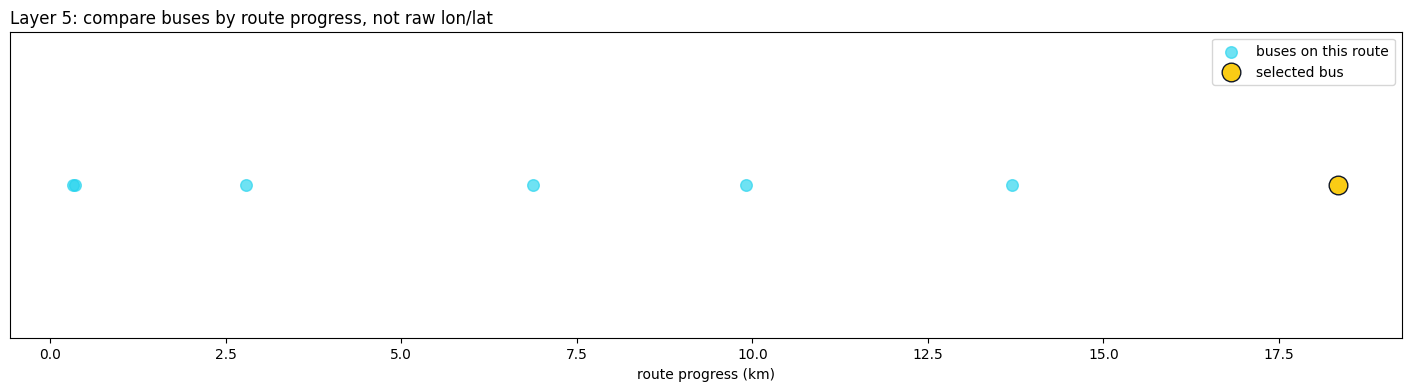

In [16]:
fig, ax = plt.subplots(figsize=(14, 3.8), constrained_layout=True)
ax.scatter(progress_df["progress_km"], [1] * progress_df.height, s=70, color="#22d3ee", alpha=0.65, label="buses on this route")
ax.scatter([bus_projection["progress_m"] / 1000], [1], s=180, color="#facc15", edgecolor="#111827", label="selected bus")
ax.set_xlabel("route progress (km)")
ax.set_yticks([])
ax.set_title("Layer 5: compare buses by route progress, not raw lon/lat", loc="left")
ax.legend(loc="upper right")
plt.show()

## 7. Route quality audit

這一步不是看單一 route，而是批次檢查所有已快取的 `RouteName + Direction`。

目的：避免每條路線人工調參。pipeline 先用 `good / usable / bad` 判斷哪些 route 可以進入 route progress 和 delay signal。

In [ ]:
ROUTE_QUALITY_FILE = DATA / "route-quality" / "manifest.json"
route_quality = json.loads(ROUTE_QUALITY_FILE.read_text())

quality_df = pl.DataFrame(route_quality["routes"])
print(route_quality["summary"])
quality_df.select(
    "routeName", "direction", "subRouteName", "quality", "stopsCount",
    "medianDistanceToRouteMeters", "p95DistanceToRouteMeters",
    "maxDistanceToRouteMeters", "badStopRatio"
).sort("p95DistanceToRouteMeters", descending=True).head(12)

In [ ]:
quality_counts = quality_df.group_by("quality").len().sort("quality")
fig, ax = plt.subplots(figsize=(7, 3.6), constrained_layout=True)
ax.bar(quality_counts["quality"], quality_counts["len"], color=["#22c55e", "#facc15", "#ef4444"][: quality_counts.height])
ax.set_title("Route geometry quality bands", loc="left")
ax.set_ylabel("route directions")
plt.show()